**INTRODUCTION**

Dendritic cells are key intermediates between innate immune sensing and adaptive immune activation, playing a critical role in anti-tumor immunity. Multiple dendritic cell subsets, including cDC1, cDC2, and plasmacytoid dendritic cells, emerge through highly coordinated differentiation programs which are initiated by specific transcriptional regulators. Transcription factors such as IRF4, IRF8, and SPIB are known for their function in maintaining the dendritic cell identity. This study aims to understand the influence of chromatin regulation, especially the histone deacetylase HDAC1, on the specification and functional maturation of the dendritic cell lineage. Since, the transcription factor activity is usually unanticipated, epigenetic regulators may function as upstream modulators, helping determine the fate of immune cells. To investigate this, the authors in the study integrated RNA-seq, ATAC-seq, and CUT&RUN analyses to provide for a comprehensive examination to understand the HDAC1-dependent changes in chromatin accessibility and histone modifications that are linked to gene expression programs. Together, this multi-omic approach provides insight into how HDAC1 preserves dendritic cell subset identity and helps generate anti-tumor immune responses.

**METHODS**

**Data Acquisition**  
The data in the paper was acquired through the GEO accession code using the GEO website. The reads were taken from the ATAC sequencing experiment but the reference genome, and the gtf files were downloaded through GENCODE. The remaining data required for the replication of the figures was also extracted from the GEO website using the GEO accession number given in the paper.


**Quality Control and Read Preprocessing**  
Raw sequencing reads were first evaluated using FastQC to assess the quality metrics, including base quality scores, GC content, and adapter contamination. Adapter trimming and quality filtering were performed using Trimmomatic to remove sequencing adapters and low-quality bases. This ensured that only high-quality reads were retained for alignment. The aggregated quality control metrics across all samples were then summarized using MultiQC.

**Alignment to the Reference Genome**  
Preprocessed reads were aligned to the mouse reference genome (GRCm38) using Bowtie2, and alignment parameters that helped map short fragments were chosen based on the ATAC-seq data. Alignment statistics were then assessed using samtools flagstat and BAM files were generated. These BAM files were then sorted and indexed using samtools sort and samtools index to generate data files to conduct the downstream data analysis.

**Mitochondrial Read Removal and Coverage Track Generation**  
To reduce the bias caused due to the high number of mitochondrial DNA in ATAC-seq libraries, reads aligning to mitochondrial chromosomes were removed using REMOVE_MITO. Genome-wide chromatin accessibility signal tracks were then generated from filtered BAM files using deepTools bamCoverage, which helped produce normalized bigWig files useful for further comparison among samples. 

**Global Accessibility Profiling and Signal Coverage Plots**  
Global chromatin accessibility patterns were summarized using deepTools multiBigwigSummary, allowing for comparison of signal distributions across samples. The aggregated accessibility profiles in the annotated gene regions were generated using deepTools computeMatrix. The signal coverage plots for these were generated using deepTools plotProfile, helping understand the patterns across various gene bodies and regulatory regions.

**Peak Calling and Differential Chromatin Accessibility**  
Regions of open chromatin were then identified through peak calling using MACS3. This step helped in especially defining the genomic regions showing significant ATAC-seq enrichment. The Differential Chromatin Accessibility analysis was then performed in R using DiffBind in combination with DESeq2. The read counts were quantified over the consensus peaks, and statistical testing was performed to identify region with significant differences in accessibility between WT and KO samples for each cell type.

**Peak Annotation and Motif Enrichment Analysis**  
Identified ATAC-seq peaks were then annotated to nearby genomic features using HOMER annotatePeaks. This helped in the classification of peaks based on the proximity to the promoters, regulatory regions, introns, and exons. To further identify the transcription factors driving chromatin accessibility changes, motif enrichment analysis was performed on ATAC-seq peaks using HOMER findMotifsGenome. 

**Figure Reproduction**  
Figures 6A to 6F were reproduced from the original publication. ATAC sequencing data, H3K27ac, and RNA sequencing data were combined to reproduce figures 6A to 6F and capture the accessibility patterns. Furthermore, profile plots and heatmaps were used to visualize average ATAC seq and H2K27ac signals. While the results generated from the differential analysis using DESeq2, and log2foldchanges from ATAC seq and RNA seq, were integrated to produce the RNA-ATAC scatter plots.


**QUALITY CONTROL EVALUATION** 

Overall, the ATAC-seq data demonstrated strong sequencing quality across all samples, supporting their suitability for downstream chromatin accessibility analysis. Each sample contained approximately 22–32 million reads, providing sufficient sequencing depth for ATAC-seq signal detection. Per-sequence quality metrics also showed consistently high Phred scores across reads with values exceeding 30. Adapter content increased toward the 3′ end of reads in several samples with triggering warnings for 5 reads. Adapter trimming using Trimmomatic removed a small fraction of adapter-contaminated reads (approximately 2% per sample), improving overall data quality prior to alignment. 

Collectively, these quality control demonstrates that the ATAC-seq data are high quality, and appropriate for downstream peak calling and differential chromatin accessibility analyses.

**SIGNAL COVERAGE PLOT**

Signal coverage plots generated for cDC1 and cDC2 HDAC1 knockout (KO) samples show pronounced enrichment at the transcription start site (TSS), followed by reduced accessibility across the gene body and a secondary, smaller peak near the transcription end site (TES). This pattern is seen across all the samples and is a characteristic feature of active promoters.

Across both cDC1 and cDC2 KO samples, the overall shape and magnitude of the profiles are highly similar between biological replicates, indicating strong reproducibility and high consistency in chromatin accessibility within each cell type. The sharp TSS enrichment suggests that promoter accessibility is preserved in the absence of HDAC1. The presence of the TES enrichment is indicative of some chromatin remodeling events associated with transcriptional termination. But together, these profiles demonstrate that HDAC1 knockout cells retain global promoter accessibility patterns, providing a foundation for downstream differential accessibility analyses.


![img](/projectnb/bf528/students/shrjain/final-project-template-shriyajain22/results/plotprofile/cDC1_KO_1_signal_coverage.png)

**Fig 1.** cDC1_KO_1 gene body profile  
Average chromatin signal across gene bodies for the cDC1_KO_1 sample, aligned from 2 kb upstream of the transcription start site (TSS) through the transcription end site (TES) to 2 kb downstream. Signal is enriched at the TSS, with lower, relatively uniform signal across the gene body and a smaller enrichment near the TES.

![img](/projectnb/bf528/students/shrjain/final-project-template-shriyajain22/results/plotprofile/cDC1_KO_2_signal_coverage.png)

**Fig 2.** cDC1_KO_2 gene body profile  
Average chromatin signal across gene bodies for the cDC1_KO_2 sample, aligned from 2 kb upstream of the TSS through the TES to 2 kb downstream. A strong peak is observed at the TSS, followed by reduced signal across the gene body and a modest increase near the TES, showing a profile similar to the cDC1_KO_1 replicate.

![img](/projectnb/bf528/students/shrjain/final-project-template-shriyajain22/results/plotprofile/cDC2_KO_1_signal_coverage.png)

**Fig 3.** cDC2_KO_1 gene body profile  
Average chromatin signal across gene bodies for the cDC2_KO_1 sample, aligned relative to the TSS and TES with 2 kb flanking regions. The profile shows pronounced enrichment at the TSS, lower signal across the gene body, and a secondary enrichment near the TES.

![img](/projectnb/bf528/students/shrjain/final-project-template-shriyajain22/results/plotprofile/cDC2_KO_2_signal_coverage.png)

 **Fig 4.** cDC2_KO_2 gene body profile  
Average chromatin signal across gene bodies for the cDC2_KO_2 sample, aligned from 2 kb upstream of the TSS through the TES to 2 kb downstream. Signal enrichment is highest at the TSS, decreases across the gene body, and shows a smaller peak near the TES, consistent with the cDC2_KO_1 replicate.

**HEATMAP**

Correlation heatmaps generated using DiffBind were used to assess ATAC-seq chromatin accessibility across samples within each subset. In both cDC1 and cDC2 datasets, biological replicates cluster tightly together, demonstrating high correlation and strong reproducibility of chromatin accessibility profiles. Replicates from the same condition (WT or KO) exhibit higher correlation with each other than with samples from the opposite condition. This indicates that genotype plays a role in determining the accessibility differences. Overall correlation values are high across all samples, reflecting consistent data and reliable signal quality. 

Hierarchical clustering further reveals clear separation between WT and HDAC1 knockout samples within both cDC1 and cDC2 populations. In the cDC1 heatmap, WT replicates cluster together and are distinct from KO replicates. A similar pattern is also observed in cDC2 samples, where KO and WT groups separate out from each other. These results confirm that chromatin accessibility profiles are reproducible, but are also condition-specific. It also demonstrates the role of these factors in determining the regulatory functions to maintain normal accessibility in the dendritic cells. 


![img](/projectnb/bf528/students/shrjain/final-project-template-shriyajain22/results/differential_chromatin_analysis/heatmap1.png)

**Fig 5.** Correlation heatmap of ATAC-seq signal in cDC1 samples  
Heatmap showing pairwise Pearson correlation coefficients between cDC1 ATAC-seq samples based on log2(count+1) normalized read counts across consensus peaks. Hierarchical clustering is shown along both axes. Color intensity represents correlation strength, ranging from lower similarity (blue) to higher similarity (red). Sample annotations indicate replicate number, experimental condition (WT or KO), and cell type.

![img](/projectnb/bf528/students/shrjain/final-project-template-shriyajain22/results/differential_chromatin_analysis/heatmap2.png)

**Fig 6.** Correlation heatmap of ATAC-seq signal in cDC2 samples  
Heatmap showing pairwise Pearson correlation coefficients between cDC2 ATAC-seq samples based on log2(count+1) normalized read counts across consensus peaks. Hierarchical clustering is shown along both axes. Color intensity represents correlation strength, ranging from lower similarity (blue) to higher similarity (red). Sample annotations indicate replicate number, experimental condition (WT or KO), and cell type.

**PRINCIPAL COMPONENT ANALYSIS (PCA) PLOTS**

Principal component analysis (PCA) was performed using DiffBind to assess global patterns of chromatin accessibility and evaluate sample similarity within each subset. In both cDC1 and cDC2 datasets, samples separate along the first principal component (PC1). Along PC1, WT and HDAC1 knockout samples are clearly separated, indicating that genotype is one of the major factors for differences in chromatin accessibility profiles. It also suggests that loss of HDAC1 results in widespread and predictable changes in chromatin accessibility across the subsets. subsets.  

The second principal component (PC2), with approximately 31–32% of the variance, captures variability between biological replicates within each condition. Replicates from the same genotype are closely clustered to each other,indicating high reproducibility with some amount of variability. Both the WT and KO samples remain distinct across both principal components in cDC1 and cDC2 populations, proving the idea that HDAC1 status significantly influences global chromatin accessibility. 


![img](/projectnb/bf528/students/shrjain/final-project-template-shriyajain22/results/differential_chromatin_analysis/pca1.png)

**Fig 7.** Principal component analysis (PCA) of cDC1 samples based on chromatin accessibility  
PCA of cDC1 samples shows separation between WT and KO conditions along the first principal component (PC1, 46.3% of variance), indicating condition-dependent differences in chromatin accessibility. Biological replicates within each condition cluster closely, demonstrating good reproducibility. PC2 (30.9% of variance) captures additional variability between replicates but does not obscure the primary separation driven by genotype.


![img](/projectnb/bf528/students/shrjain/final-project-template-shriyajain22/results/differential_chromatin_analysis/pca2.png)

**Fig 8.** Principal component analysis (PCA) of cDC2 samples based on chromatin accessibility  
PCA of cDC1 samples shows separation between WT and KO conditions along the first principal component (PC1, 46.3% of variance), indicating condition-dependent differences in chromatin accessibility. Biological replicates within each condition cluster closely, demonstrating good reproducibility. PC2 (32.4% of variance) captures additional variability between replicates but does not obscure the primary separation driven by genotype.

**DIFFERENTIAL CHROMATIN ACCESSIBILITY ANALYSIS** 

In cDC1 cells, DiffBind identified multiple genomic regions producing significant results in chromatin accessibility between WT and HDAC1 knockout conditions. These differentially accessible peaks span multiple chromosomes and include both gains and losses of accessibility in the samples. The presence of both increased and decreased accessibility suggests that HDAC1 plays a role in regulating chromatin structure, with both repressing and maintaining accessibility at particular regulatory regions. These findings are consistent with the correlation and PCA analyses which demonstrated clear separation of cDC1 samples. This supports the conclusion that the loss of  HDAC1 results in widespread as well as condition-specific remodeling of chromatin in cDC1 cells.

On the other hand, differential accessibility analysis for the cDC2 population did not yield any peaks for FDR ≤ 0.05 threshold. This absence of significant differentially accessible regions suggests that HDAC1 loss has a significantly prominent effect on chromatin accessibility in cDC1 cells than in cDC2 cells, or the changes in cDC2 cells are slightly subtle compared to cDC1 cells. In a nutshell, both the results suggest that HDAC1 has a cell specific role in regulating chromatin accessibility, with subsequently stronger regulatory effects observed in cDC1 cells.

**REPLICATION OF FIGURES**

**Replication of Figures 6A and 6B**

In cDC1 cells, DiffBind identified multiple genomic regions producing significant results in chromatin accessibility between WT and HDAC1 knockout conditions. These differentially accessible peaks span multiple chromosomes and include both gains and losses of accessibility in the samples. The presence of both increased and decreased accessibility suggests that HDAC1 plays a role in regulating chromatin structure, with both repressing and maintaining accessibility at particular regulatory regions. These findings are consistent with the correlation and PCA analyses which demonstrated clear separation of cDC1 samples. This supports the conclusion that the loss of  HDAC1 results in widespread as well as condition-specific remodeling of chromatin in cDC1 cells.

On the other hand, differential accessibility analysis for the cDC2 population did not yield any peaks for FDR ≤ 0.05 threshold. This absence of significant differentially accessible regions suggests that HDAC1 loss has a significantly prominent effect on chromatin accessibility in cDC1 cells than in cDC2 cells, or the changes in cDC2 cells are slightly subtle compared to cDC1 cells. In a nutshell, both the results suggest that HDAC1 has a cell specific role in regulating chromatin accessibility, with subsequently stronger regulatory effects observed in cDC1 cells.

WT samples show a strong and symmetric enrichment of H3K27ac with peaks centered at midpoints. The HDAC1 knockout samples show a subsequently reduced H3K27ac signal intensity across the same regions, especially at the peaks. This indicates the alteration in the histone acetylation because of the loss of HDAC1. Heatmaps further show a diminished and less intense H3K27ac enrichment across individual peaks in the knockout condition with the peak-centered signal being evident, suggesting that regulatory elements are retained but only exhibit a reduced activity. Based on these figures, we can say that HDAC1 plays a role in maintaining appropriate levels of H3K27ac in the active regulatory regions, and its loss leads to an increase in the activation of histones. 


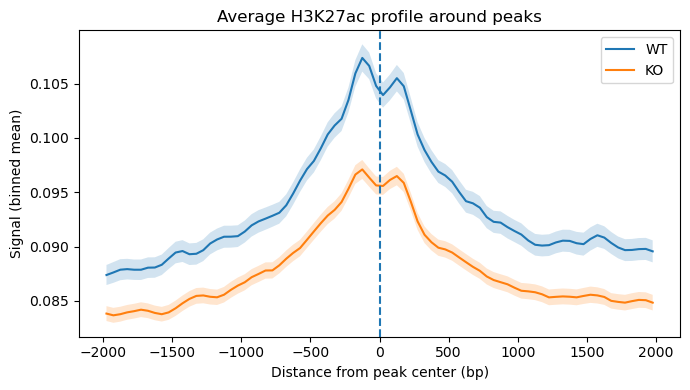

**Fig 9.** Average H3K27ac signal profile around peak centers in WT and KO samples  
Metagene analysis showing the average H3K27ac ChIP-seq signal centered on peak summits (±2 kb) for WT and KO conditions. The dashed vertical line denotes the peak center (0 bp). WT samples exhibit a higher and sharper enrichment of H3K27ac signal at peak centers compared to KO samples, indicating reduced enhancer-associated acetylation in the KO condition. Shaded regions represent variability across peaks, highlighting consistent signal differences between conditions.


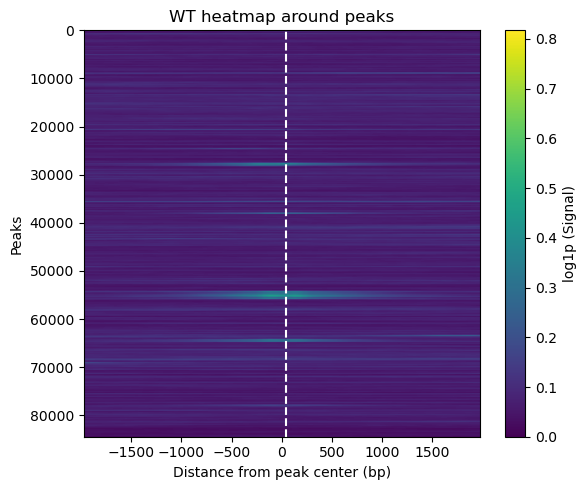

**Fig 10.** WT heatmap around peak centers  
Heatmap showing H3K27ac ChIP-seq signal intensity (log-scaled) for wild-type (WT) samples across all called peaks. Each row represents an individual peak, and columns represent distance from the peak center (±2 kb). Peaks are aligned at their centers (0 bp, dashed vertical line). Strong enrichment of H3K27ac signal is observed near peak centers, consistent with active regulatory regions in WT cells.

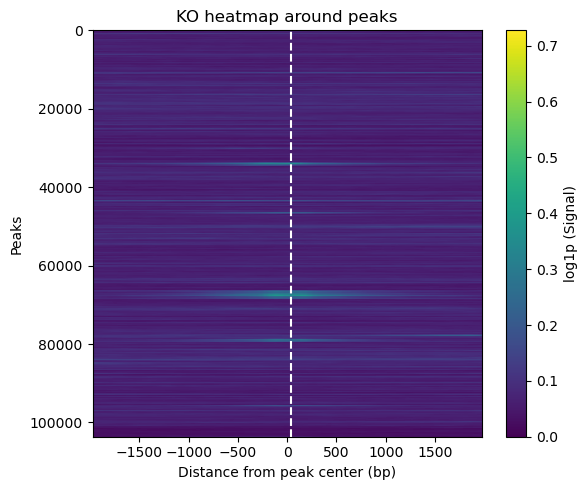
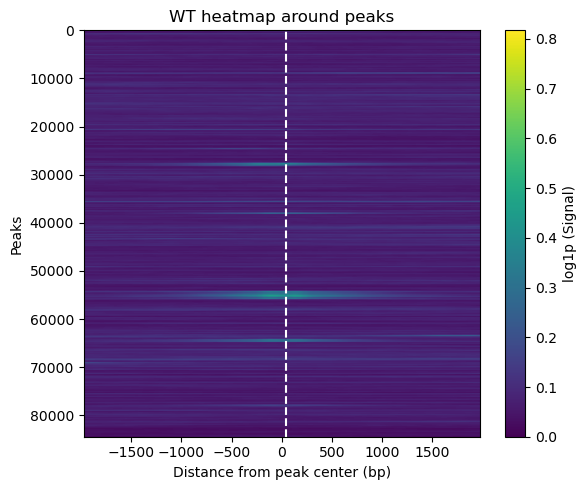

**Fig 11.** KO heatmap around peak centers  
Heatmap displaying H3K27ac ChIP-seq signal intensity (log-scaled) for knockout (KO) samples across all called peaks, aligned at peak centers (0 bp, dashed vertical line). Compared to WT, overall signal intensity near peak centers appears reduced, indicating decreased H3K27ac enrichment at regulatory regions in the KO condition.

**Replication of Figures 6C and 6E**

For both the scatter plots, the majority of features cluster near the origin, indicating that most of the genes do not undergo changes in the expression. A small proportion of the genes show changes in the RNA expression without any changes in the chromatin accessibility. This idea suggests that regulation at the transcriptional or post-transcriptional level is independent of chromatin remodeling. Very few segments of genes show changes in both RNA expression and ATAC-seq signal, indicating that there is a small percentage of transcriptional changes that are directly related to altered chromatin accessibility. Based on these results, we can infer that loss of HDAC1 majorly impacts the gene expression programs. Its effects on chromatin accessibility and transcription are very minimal and are very indirect. 

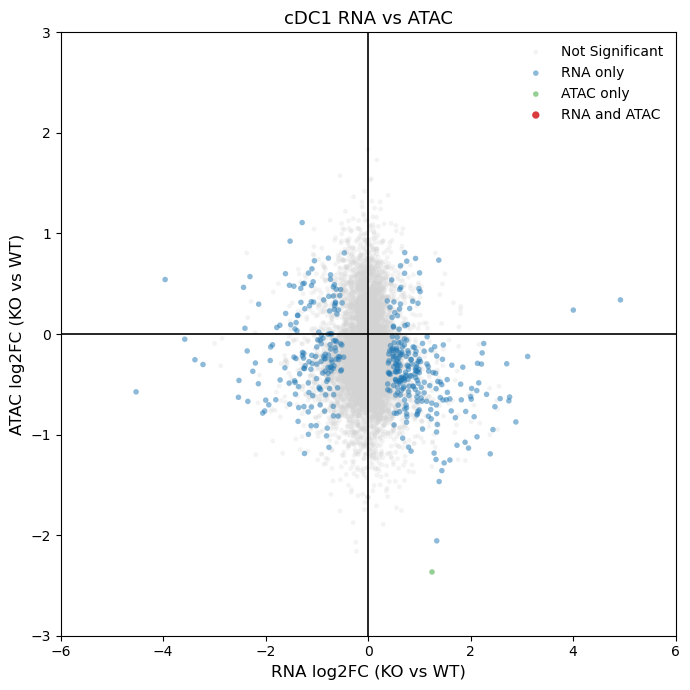

**Fig 12.** cDC1 RNA vs ATAC differential analysis (KO vs WT)  
Scatter plot comparing RNA-seq log2 fold change (KO vs WT) and ATAC-seq log2 fold change (KO vs WT) for cDC1 cells. Each point represents a gene-associated regulatory region, with vertical and horizontal lines indicating no change in RNA expression or chromatin accessibility, respectively. Points are colored by significance category, highlighting genes showing changes in RNA only, ATAC only, both RNA and ATAC, or neither. This plot illustrates the relationship between transcriptional changes and chromatin accessibility in cDC1 upon knockout.

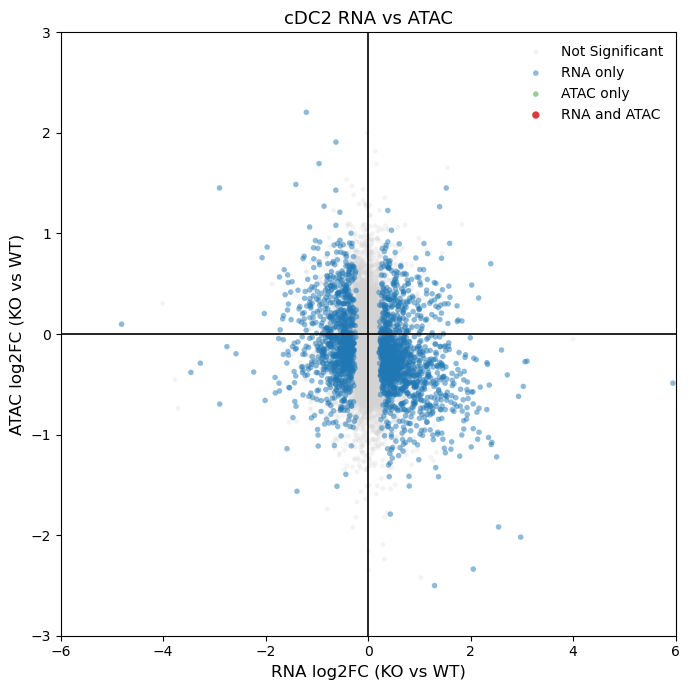

**Fig 13.** cDC2 RNA vs ATAC differential analysis (KO vs WT)  
Scatter plot comparing RNA-seq log2 fold change (KO vs WT) and ATAC-seq log2 fold change (KO vs WT) for cDC2 cells. Each point corresponds to a gene-associated chromatin region, with axes centered at zero to denote no differential change. Points are categorized based on whether differential signal is detected in RNA-seq, ATAC-seq, both, or neither. The distribution reflects the degree of concordance between chromatin accessibility and gene expression changes in cDC2 following knockout.

**Replication of 6D and 6F**

Genome browser track figures demonstrate the correlation of chromatin accessibility and histone modification between WT and knockout samples in cDC1 and cDC2 cells. The ATAC-seq tracks highlight regions of open chromatin. These are majorly consistent between replicates but show differences between WT and KO conditions, indicating that the knockout affects chromatin accessibility at specific genomic regions. The H3K27ac signal is stronger at accessible regions in WT samples but is altered in the knockout, suggesting that the regulatory activity changes when the factor is lost. The IgG control tracks show low signal uniformity, suggesting that the observed patterns in ATAC-seq and H3K27ac are specific and not merely due to background noise.

![img](/projectnb/bf528/students/shrjain/final-project-template-shriyajain22/results/replicated_figures/figure6d.png)


**Fig 14.** Genome browser view of chromatin accessibility and histone modification at a representative locus (chrX)  
Tracks show ATAC-seq signal for cDC1 and cDC2 populations under WT (black) and KO (red) conditions, alongside H3K27ac ChIP-seq and IgG control tracks. Gene annotations are displayed at the top.

![img](/projectnb/bf528/students/shrjain/final-project-template-shriyajain22/results/replicated_figures/figure6f.png)

**Fig 15.** Genome browser view of chromatin accessibility and histone modification at a representative locus (chrX)  
Tracks show ATAC-seq signal for cDC1 and cDC2 populations under WT (black) and KO (red) conditions, alongside H3K27ac ChIP-seq and IgG control tracks. Gene annotations are displayed at the top.

**MOTIF FINDING**

Motif enrichment analysis of ATAC-seq peaks showed consistent results and strongly enriched DNA sequence motifs for both WT and knockout for the cDC1 and cDC2 samples. The top enriched motif in all conditions closely matches the SPI1 transcription factor. The large presence of these particular motifs with significant p-value indicates the good enrichment results. 

![img](/projectnb/bf528/students/shrjain/final-project-template-shriyajain22/results/motifs/cdc1_ko1.png)
**Fig 16.** Top enriched motif for cDC1_KO1


![img](/projectnb/bf528/students/shrjain/final-project-template-shriyajain22/results/motifs/cdc1_ko2.png)
**Fig 17.** Top enriched motif for cDC1_KO2


![img](/projectnb/bf528/students/shrjain/final-project-template-shriyajain22/results/motifs/cdc1_wt1.png)
**Fig 18.** Top enriched motif for cDC1_WT1


![img](/projectnb/bf528/students/shrjain/final-project-template-shriyajain22/results/motifs/cdc1_wt2.png)
**Fig 19.** Top enriched motif for cDC1_WT2


![img](/projectnb/bf528/students/shrjain/final-project-template-shriyajain22/results/motifs/cdc2_ko1.png)
**Fig 20.** Top enriched motif for cDC2_KO1


![img](/projectnb/bf528/students/shrjain/final-project-template-shriyajain22/results/motifs/cdc2_ko2.png)
**Fig 21.** Top enriched motif for cDC2_KO2


![img](/projectnb/bf528/students/shrjain/final-project-template-shriyajain22/results/motifs/cdc2_wt1.png)
**Fig 22.** Top enriched motif for cDC2_WT1


![img](/projectnb/bf528/students/shrjain/final-project-template-shriyajain22/results/motifs/cdc2_wt2.png)
**Fig 23.** Top enriched motif for cDC2_WT2
